# Experimento 3 · Distribución real antes de redistribuir los pesos

**Objetivo:** conocer los valores de ozono y sus patrones de bits antes de diseñar otra codificación. Esta etapa no ejecuta ataques ni utiliza el LSTM.

Usa el kernel **Python (lorawan11 .venv)**. Hay una sola celda ejecutable e independiente de los notebooks anteriores. Lee `data/raw/2025O3.xls` sin modificarlo; no escribe archivos.

## Qué vamos a mirar y por qué

- **Resumen por estación:** cobertura, media, mediana, percentil 95 y máximo. La media no sustituye la distribución: puede ocultar valores raros cerca del umbral.
- **Histograma de mensajes:** cada observación válida estación–hora es una posible medición transmitida; no son capturas reales de paquetes LoRaWAN. La curva adicional da el mismo peso a cada estación con datos, aunque tengan distinta cobertura.
- **Detalle cerca de 155 ppb:** usamos este corte como umbral experimental de Fase I, no como reproducción completa de una declaración administrativa. La franja de ±32 ppb es exploratoria, no una etiqueta de vulnerabilidad.
- **Bits encendidos:** examinamos la representación original, entera a 1 ppb por unidad. Un flip de un bit apagado suma su peso; uno encendido lo resta. No son porcentajes de éxito de un ataque.

Los faltantes permanecen como faltantes y se excluyen de los cálculos, sin interpolar ni sustituirlos por cero. Un cero registrado sí cuenta como medición. La cobertura usa las filas horarias presentes en el archivo. La conversión horaria es la del módulo de ingesta del proyecto; todavía tiene un supuesto documentado sobre HORA 1–24.

## Cómo servirá para diseñar la contramedida

La tabla `frecuencia_ppb` conserva el número de apariciones de **cada valor exacto** y permite evaluar después una codificación sin repetir el cálculo para miles de mensajes idénticos. Para un ataque de un mensaje cuya transformación depende solo de su valor, esta agrupación conserva exactamente los conteos de cruces locales; no es una aproximación basada en promedios.

Para evaluar el efecto en la red habrá que volver a los registros con estación y hora: alterar una lectura no implica ocultar las demás excedencias. Conservamos `matriz` y `datos_validos` para ese paso.

Diseñar con 2025 y evaluar en ese mismo año será un resultado exploratorio. Una vez elegidos y fijados los pesos y la regla de codificación, otros años permitirán comprobar generalización sin reajustar la propuesta a sus resultados. El máximo observado no define por sí solo el rango que debe soportar el formato.


2025: 33 estaciones con datos | 8,760 filas horarias
Estaciones sin datos: ['COY', 'SFE', 'SJA']
Mensajes válidos: 218,823 | rango: 0–168 ppb
Franja exploratoria inclusiva: 123–187 ppb: 1,059 mensajes
Lecturas >= 155 ppb: 25; esto NO es el número de contingencias.

Resumen de TODAS las estaciones (sin filtrar por cobertura):


,n_mensajes,cobertura_pct,media_ppb,mediana_ppb,p95_ppb,maximo_ppb,n_cerca_umbral,n_ge_umbral
station,,,,,,,,
ACO,5710,65.18,32.31,26.0,81.0,137,7,0
AJM,7765,88.64,43.92,38.0,99.0,164,75,3
AJU,2422,27.65,37.65,31.0,85.0,141,5,0
ATI,7585,86.59,30.55,23.0,82.0,153,20,0
BJU,4804,54.84,36.27,26.0,102.0,166,72,2
CAM,7923,90.45,27.85,17.0,88.0,155,47,1
CCA,8491,96.93,35.44,26.0,98.0,149,69,0
CHO,3008,34.34,35.88,32.0,86.0,127,1,0
CUA,4361,49.78,43.06,38.0,99.0,166,60,1



Diez valores más frecuentes (no necesariamente los más peligrosos):


,n_mensajes,pct_mensajes,pct_promedio_estaciones
ppb,,,
2,10314,4.713,4.635
1,7836,3.581,3.432
3,7273,3.324,3.283
4,5488,2.508,2.463
5,4742,2.167,2.116
6,4311,1.970,1.923
7,4172,1.907,1.872
11,4047,1.849,1.807
10,3975,1.817,1.777



Estado de los 16 bits de la representación ORIGINAL:


,bit,peso_original_ppb,pct_encendido_todos,pct_encendido_cerca
0,0,1,49.98,54.49
1,1,2,50.66,48.35
2,2,4,46.35,54.67
3,3,8,43.34,53.64
4,4,16,39.93,42.68
5,5,32,28.19,33.71
6,6,64,15.38,32.48
7,7,128,0.33,67.52
8,8,256,0.00,0.00
9,9,512,0.00,0.00


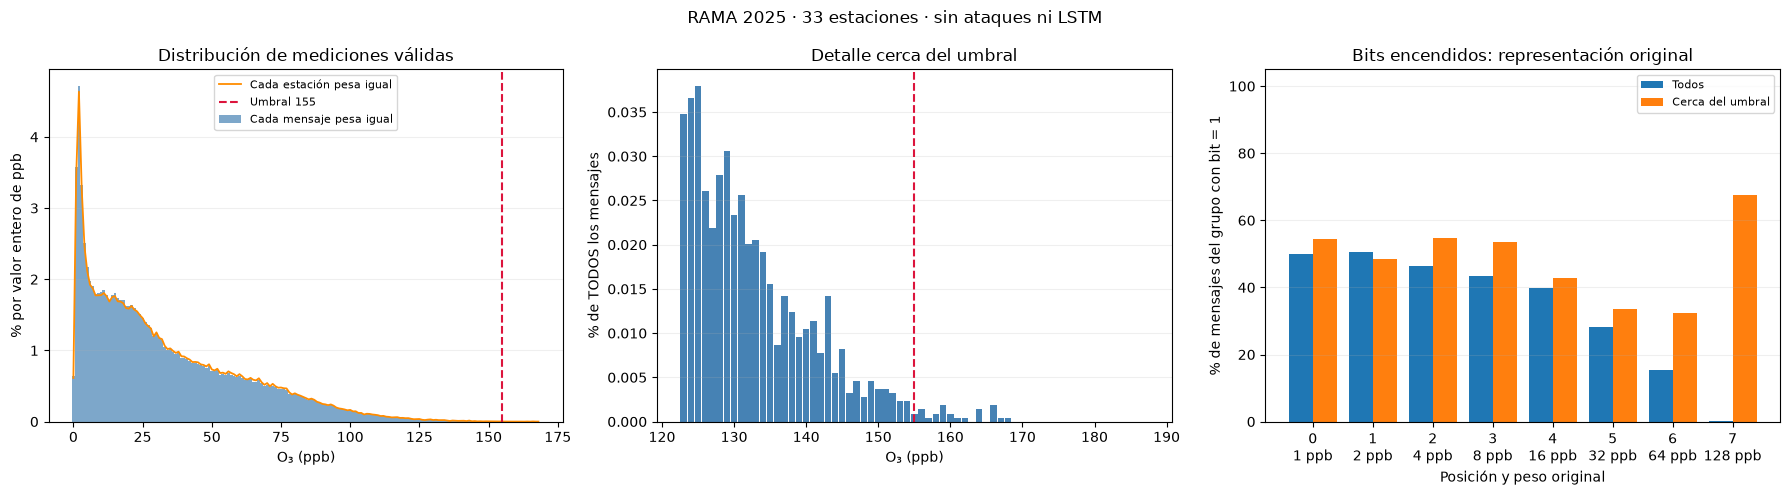

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

actual = Path.cwd().resolve()
RAIZ = next((p for p in (actual, *actual.parents)
             if (p / "src/ingest/rama.py").is_file()), None)
if RAIZ is None:
    raise RuntimeError("Abre este notebook dentro del repositorio.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.ingest.rama import load_wide, to_long

ANIO = 2025
UMBRAL_PPB = 155
MARGEN_PPB = 32
archivo = RAIZ / "data" / "raw" / f"{ANIO}O3.xls"
if not archivo.is_file():
    raise FileNotFoundError(f"No se encontró el dataset: {archivo}")

datos = to_long(load_wide(archivo), "O3")
if datos.duplicated(["timestamp", "station"]).any():
    raise ValueError("Hay registros estación-hora duplicados; revísalos antes de contar.")
if not datos["timestamp"].dt.year.eq(ANIO).all():
    raise ValueError("El archivo contiene fechas fuera del año solicitado.")
matriz_completa = datos.pivot(index="timestamp", columns="station", values="value").sort_index()
sin_datos = matriz_completa.columns[matriz_completa.isna().all()].tolist()
matriz = matriz_completa.drop(columns=sin_datos)
datos_validos = datos.dropna(subset=["value"]).copy()
if datos_validos.empty:
    raise ValueError("No hay mediciones válidas.")
valores = datos_validos["value"].to_numpy(dtype=float)
if (not np.isfinite(valores).all() or not np.equal(valores, np.rint(valores)).all()
        or (valores < 0).any() or (valores > 32767).any()):
    raise ValueError("Se esperaban ppb enteros no negativos compatibles con el campo original.")
datos_validos["ppb"] = valores.astype(np.int64)

# Cada fila válida representa una oportunidad de modificar un mensaje.
grupo = datos_validos.groupby("station")["ppb"]
resumen_estaciones = grupo.agg(n_mensajes="size", media_ppb="mean",
                               mediana_ppb="median", maximo_ppb="max")
resumen_estaciones["p95_ppb"] = grupo.quantile(0.95)
resumen_estaciones["cobertura_pct"] = 100 * resumen_estaciones["n_mensajes"] / len(matriz)
cerca = datos_validos["ppb"].between(UMBRAL_PPB - MARGEN_PPB, UMBRAL_PPB + MARGEN_PPB)
sobre = datos_validos["ppb"].ge(UMBRAL_PPB)
resumen_estaciones["n_cerca_umbral"] = (
    datos_validos.loc[cerca].groupby("station").size()
    .reindex(resumen_estaciones.index, fill_value=0))
resumen_estaciones["n_ge_umbral"] = (
    datos_validos.loc[sobre].groupby("station").size()
    .reindex(resumen_estaciones.index, fill_value=0))
resumen_estaciones = resumen_estaciones[
    ["n_mensajes", "cobertura_pct", "media_ppb", "mediana_ppb", "p95_ppb",
     "maximo_ppb", "n_cerca_umbral", "n_ge_umbral"]].sort_index()

# Frecuencias exactas: no reemplazamos la distribución por una media.
eje_ppb = pd.Index(range(int(valores.max()) + 1), name="ppb")
conteos = datos_validos["ppb"].value_counts().reindex(eje_ppb, fill_value=0)
por_estacion = pd.crosstab(datos_validos["ppb"], datos_validos["station"]).reindex(
    eje_ppb, fill_value=0)
por_estacion_pct = por_estacion.div(por_estacion.sum(axis=0), axis=1) * 100
frecuencia_ppb = pd.DataFrame({
    "n_mensajes": conteos,
    "pct_mensajes": 100 * conteos / len(datos_validos),
    "pct_promedio_estaciones": por_estacion_pct.mean(axis=1),
})
assert int(frecuencia_ppb["n_mensajes"].sum()) == len(datos_validos)
assert np.isclose(frecuencia_ppb["pct_mensajes"].sum(), 100)
assert np.isclose(frecuencia_ppb["pct_promedio_estaciones"].sum(), 100)

bits = np.arange(16)
pesos_originales = 1 << bits
pesos_originales[-1] = -32768  # Bit de signo del entero original de 16 bits.
v = datos_validos["ppb"].to_numpy()
encendidos = (v[:, None] >> bits) & 1
patrones_bits = pd.DataFrame({
    "bit": bits,
    "peso_original_ppb": pesos_originales,
    "pct_encendido_todos": encendidos.mean(axis=0) * 100,
    "pct_encendido_cerca": (
        encendidos[cerca.to_numpy()].mean(axis=0) * 100
        if cerca.any() else np.full(16, np.nan)),
})

print(f"{ANIO}: {len(matriz.columns)} estaciones con datos | {len(matriz):,} filas horarias")
print(f"Estaciones sin datos: {sin_datos}")
print(f"Mensajes válidos: {len(v):,} | rango: {v.min()}–{v.max()} ppb")
print(f"Franja exploratoria inclusiva: {UMBRAL_PPB - MARGEN_PPB}–"
      f"{UMBRAL_PPB + MARGEN_PPB} ppb: {int(cerca.sum()):,} mensajes")
print(f"Lecturas >= {UMBRAL_PPB} ppb: {int(sobre.sum()):,}; "
      "esto NO es el número de contingencias.")
print("\nResumen de TODAS las estaciones (sin filtrar por cobertura):")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(resumen_estaciones.round(2))
print("\nDiez valores más frecuentes (no necesariamente los más peligrosos):")
display(frecuencia_ppb.nlargest(10, "n_mensajes").round(3))
print("\nEstado de los 16 bits de la representación ORIGINAL:")
display(patrones_bits.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.bar(frecuencia_ppb.index, frecuencia_ppb["pct_mensajes"], width=1,
       color="steelblue", alpha=0.7, label="Cada mensaje pesa igual")
ax.plot(frecuencia_ppb.index, frecuencia_ppb["pct_promedio_estaciones"],
        color="darkorange", lw=1.3, label="Cada estación pesa igual")
ax.axvline(UMBRAL_PPB, color="crimson", ls="--", label=f"Umbral {UMBRAL_PPB}")
ax.set(title="Distribución de mediciones válidas",
       xlabel="O₃ (ppb)", ylabel="% por valor entero de ppb")
ax.legend(fontsize=8)

ax = axes[1]
# Mantenemos el denominador global; no renormalizamos la franja al 100%.
zoom = frecuencia_ppb.reindex(range(UMBRAL_PPB - MARGEN_PPB,
                                   UMBRAL_PPB + MARGEN_PPB + 1), fill_value=0)
ax.bar(zoom.index, zoom["pct_mensajes"], width=0.9, color="steelblue")
ax.axvline(UMBRAL_PPB, color="crimson", ls="--")
ax.set(title="Detalle cerca del umbral",
       xlabel="O₃ (ppb)", ylabel="% de TODOS los mensajes")

ax = axes[2]
# Los 16 bits se muestran en la tabla; aquí ampliamos los ocho de menor peso.
b = patrones_bits.loc[patrones_bits["bit"] < 8]
ax.bar(b["bit"] - 0.2, b["pct_encendido_todos"], width=0.4, label="Todos")
ax.bar(b["bit"] + 0.2, b["pct_encendido_cerca"], width=0.4, label="Cerca del umbral")
ax.set_xticks(b["bit"], [f"{k}\n{1 << k} ppb" for k in b["bit"]])
ax.set(title="Bits encendidos: representación original",
       xlabel="Posición y peso original", ylabel="% de mensajes del grupo con bit = 1",
       ylim=(0, 105))
ax.legend(fontsize=8)
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
fig.suptitle(f"RAMA {ANIO} · {len(matriz.columns)} estaciones · sin ataques ni LSTM")
fig.tight_layout()
plt.show()


## Tus observaciones

- ¿Se parecen la media y la mediana entre estaciones? ¿Qué diferencias de cobertura ves?
No, cada estacion tiene sus propio comportamiento pues cada estaion esta en diferentes partes de la ZMVM ademas algo importante a destacar es que si se parecen las estaciones que son vecinas en area. Pero 2 estaciones alejadas no. 

- ¿Qué valores son frecuentes y cuántas lecturas quedan cerca de 155 ppb?
Los valores mas frecuentes son 1ppb hasta 11ppb estoy 100% seguro que de esas estan ubicadas en la noche. 

- ¿Cómo cambia el estado de los bits cerca del umbral respecto al conjunto completo? 
De todos los mensajes para 1pbb casi el 40% de esos mensajes estan a un bit cerca del umbral, mientras va aumentando la significacncia de los bits va bajando la cantidad de mansajes cerca del umbral. Aunque el caso del bit 7 es uno de los que mas destaca pero apenas tiene un % minimo.

- ¿Qué contribuciones tendría sentido repartir primero? Es una hipótesis: todavía hay que comparar codificaciones con el mismo presupuesto de ataque.
No tengo idea si es un bytes tiene 2 bits podriamos hacer que un flip se pueda hacer en uno de los dos bits y en algnos casos anularse porque serequeriria saber el contenido del mensaje para ser que bit atacar 

- Un bit menos pesado no garantiza evitar un cruce cuando el dato está muy cerca del umbral. Confirmo, un bit pesado solo permite acercar mucho la medida, pero los que hacen precisa la medida son los bits menos pesados. 

**Siguiente paso, después de revisar esta salida:** proponer otra distribución y definir también su codificador y decodificador. Compararemos cruces hacia arriba y hacia abajo con un solo mensaje alterado por escenario, empezando por un flip. La evaluación de dos flips en ese mismo mensaje será un presupuesto distinto. Todavía no inferiremos anulaciones de episodios oficiales a partir de una lectura.
